In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

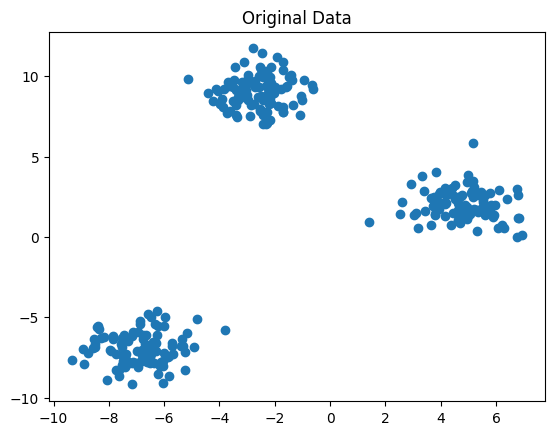

In [7]:
X, y = make_blobs(n_samples=300, centers=3, random_state=42) # 3 clusters

plt.scatter(X[:,0], X[:,1])
plt.title("Original Data")
plt.show()

In [8]:
#Steps happening here: Choose random medoids, Assign clusters, Update medoids, Repeat until medoids stop changing

class KMedoids:

    def __init__(self, k=3, max_iter=100): #Algorithm will run max 100 times to update medoids.
        self.k = k                         #randomly choose K data points as initial medoids.
        self.max_iter = max_iter

    def initialize_medoids(self, X):
        indices = np.random.choice(len(X), self.k, replace=False)
        return X[indices]

    def assign_clusters(self, X, medoids):
        clusters = []
        for point in X:
            distances = [np.linalg.norm(point - medoid) for medoid in medoids]  #calculates Euclidean distance.
            cluster_index = np.argmin(distances)
            clusters.append(cluster_index)
        return np.array(clusters)

    def update_medoids(self, X, clusters):
        new_medoids = []

        for i in range(self.k):
            cluster_points = X[clusters == i]

            distances = []
            for point in cluster_points:
                total_distance = np.sum(
                    [np.linalg.norm(point - other) for other in cluster_points]
                )
                distances.append(total_distance)

            new_medoids.append(cluster_points[np.argmin(distances)])

        return np.array(new_medoids)

    def fit(self, X):
        self.medoids = self.initialize_medoids(X)

        for _ in range(self.max_iter):
            clusters = self.assign_clusters(X, self.medoids)
            new_medoids = self.update_medoids(X, clusters)

            if np.all(self.medoids == new_medoids):
                break

            self.medoids = new_medoids

        self.clusters = clusters

    def predict(self, X):
        return self.assign_clusters(X, self.medoids)

In [5]:
kmedoids = KMedoids(k=3)
kmedoids.fit(X)

labels = kmedoids.predict(X)

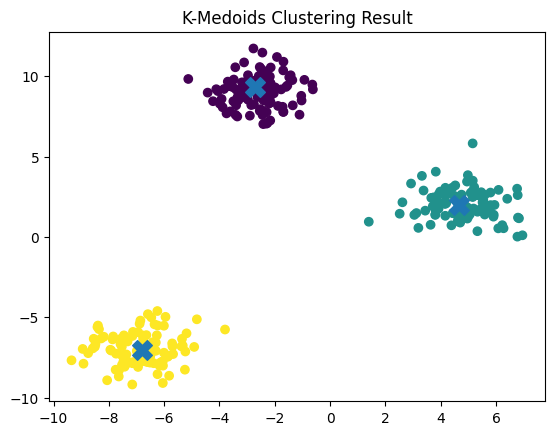

In [6]:
plt.scatter(X[:,0], X[:,1], c=labels)

plt.scatter(kmedoids.medoids[:,0],
            kmedoids.medoids[:,1],
            marker='X',
            s=200)

plt.title("K-Medoids Clustering Result")
plt.show()